# Axion production from pion scattering

Hot QCD axions produced by $a\pi \leftrightarrow \pi\pi$ below $T_c = 150$ MeV, following
Notari, Rompineve & Villadoro, [arXiv:2211.03799](https://arxiv.org/abs/2211.03799).
Runs end at 15 MeV rather than the paper's 30 MeV: for $f_a \lesssim 10^6$ GeV the axions are still coupled at
30 MeV. For $f_a \gtrsim 10^7$ GeV the two agree.

| Module / script | Role |
|---|---|
| `PyBolt/pion_phase_shifts.py` | $\pi\pi$ phase shifts $\delta^0_0, \delta^1_1, \delta^2_0$ (arXiv:1102.2183, CFD set) |
| `PyBolt/pion_amplitudes.py` | $a\pi$ amplitudes: phenomenological (from phase shifts) and LO $\chi$PT |
| `PyBolt/pion_rate.py` | destruction rate $\Gamma^>$ by `vegas`, thermal averages, `PionRateTable` |
| `tabulate_pion_rate.py` | builds `data/pion_rate_{pheno,lo}.npz` (already committed) |
| `PyBolt/processes.py` | `PionScatteringToAxion`, the collision term for the solver |
| `PyBolt/observables.py` | $\Delta N_\mathrm{eff}$ from a final spectrum |
| `fBE_pion.py` | $f_a$ scan driver |

Everything is expressed through the decay constant $f_a$; no QCD-axion mass relation is used, so the
same code applies to an ALP with the gluon coupling $a\,G\tilde G\,\alpha_s/(8\pi f_a)$ (the axion is
treated as massless during production).

Conventions: $x = m_\pi/T$, $q = k/T$, and the solver evolves $F = q^2 f$. The rate is stored as
$\Gamma^>(q, x) = (\epsilon f_\pi / 2 f_a)^2\, T\, G(q, x)$, so one table serves every $f_a$.

In [1]:
import logging
logging.disable(logging.INFO)  # silence the solver's progress log

import numpy as np
import matplotlib.pyplot as plt

import fBE_pion
from PyBolt.pion_amplitudes import EPSILON, M_PI
from PyBolt.pion_rate import PionRateTable
from PyBolt.processes import PionScatteringToAxion
from PyBolt.observables import delta_neff
from PyBolt.cosmology import h_s, s_ent
from PyBolt.constants import Zeta3

## 1. Load the rate tables

Each table holds $G(q, x)$ on a log grid. The metadata records how it was built.

In [2]:
tables = {
    "pheno": PionRateTable.load("data/pion_rate_pheno.npz"),
    "lo": PionRateTable.load("data/pion_rate_lo.npz"),
}
t = tables["pheno"]
print("q range:", 10**t.log10_q[[0, -1]], " x range:", 10**t.log10_x[[0, -1]])
print("T range [MeV]:", 1e3 * M_PI / 10**t.log10_x[[-1, 0]])
t.meta

q range: [3.16227766e-03 5.01187234e+01]  x range: [ 0.50118723 10.        ]
T range [MeV]: [ 13.8        275.34619947]


{'amplitude': 'pheno',
 'source': 'arXiv:2211.03799 eq. (E.2); phase shifts arXiv:1102.2183 CFD',
 'm_pi': 0.138,
 'f_pi': 0.0923,
 'epsilon_not_included': 0.36054421768707484,
 'neval': 200000,
 'nitn': 10,
 'n_floored': 256,
 'max_rel_sdev': 0.32527684420588177,
 'seconds': 51.1}

## 2. Momentum-dependent destruction rate

`PionScatteringToAxion(table, f_a).gamma_destruction(x, q)` returns $\Gamma^>$ in GeV.
Compare with Fig. 1 (left) of 2211.03799: the phenomenological rate follows LO $\chi$PT at low momentum
and turns over at high momentum, where LO keeps growing.

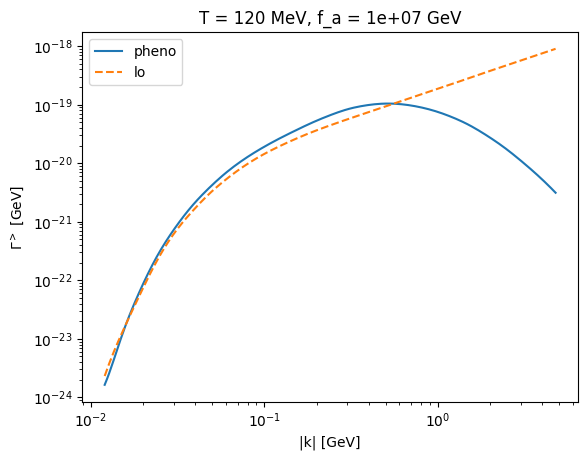

In [3]:
f_a = 1e7  # GeV
T = 0.120   # GeV
x = M_PI / T
q = np.logspace(-1, 1.6, 200)

fig, ax = plt.subplots()
for name, style in (("pheno", "-"), ("lo", "--")):
    proc = PionScatteringToAxion(tables[name], f_a)
    ax.loglog(q * T, proc.gamma_destruction(x, q), style, label=name)
ax.set_xlabel("|k| [GeV]")
ax.set_ylabel(r"$\Gamma^>$ [GeV]")
ax.set_title(f"T = {T*1e3:.0f} MeV, f_a = {f_a:.0e} GeV")
ax.legend();

## 3. Averaged rate

`averaged_rate(x)` is $\overline{\Gamma}$ of eq. (4) in 2211.03799, the rate the number-density equation uses.
The paper quotes $\overline{\Gamma} \sim 0.04\,\epsilon^2 T^3/f_a^2$ just below $T_c$ (gray line).

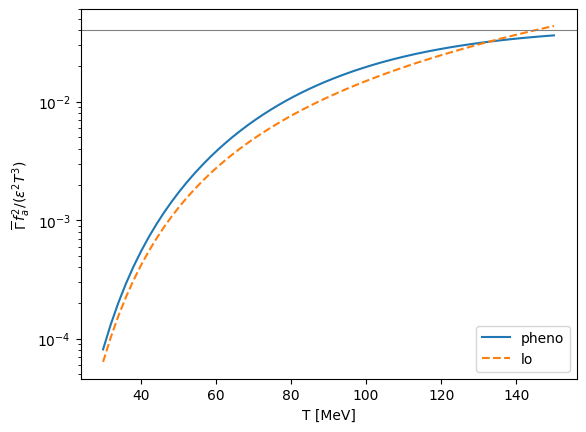

In [4]:
Ts = np.linspace(0.03, 0.150, 60)
fig, ax = plt.subplots()
for name, style in (("pheno", "-"), ("lo", "--")):
    proc = PionScatteringToAxion(tables[name], f_a)
    ratio = [proc.averaged_rate(M_PI / Ti) * f_a**2 / (EPSILON**2 * Ti**3) for Ti in Ts]
    ax.semilogy(Ts * 1e3, ratio, style, label=name)
ax.axhline(0.04, color="gray", lw=0.8)
ax.set_xlabel("T [MeV]")
ax.set_ylabel(r"$\overline{\Gamma}\, f_a^2 / (\epsilon^2 T^3)$")
ax.legend();

## 4. Solve for one $f_a$

`fBE_pion.solve_distribution(f_a, table, x, q)` solves the momentum-dependent Boltzmann equation from
150 MeV to 15 MeV, starting with no axions, and returns the final $F = q^2 f$.
The q grid must be linear, because the solver's derivative stencil assumes uniform spacing.

The result at $f_a = 2.375\times 10^7$ GeV (the paper's bound point, $\Delta N_\mathrm{eff} \approx 0.19$) is plotted against
a Bose–Einstein spectrum with the same energy density, as in Fig. 5 of the paper.

f_a = 2.375e+07 GeV, Delta N_eff = 0.2004


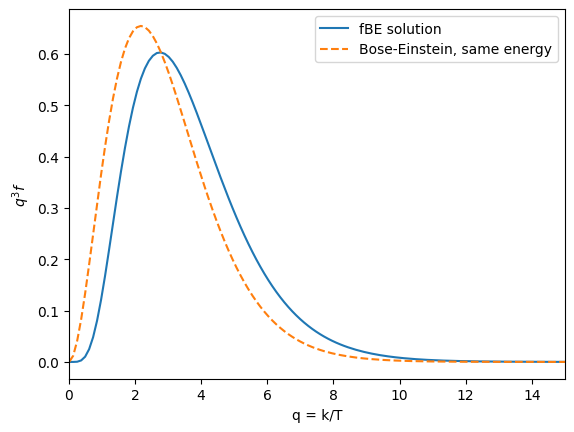

In [5]:
f_a = 2.375e7                  # GeV, bound point of 2211.03799
x_grid = fBE_pion.x_grid(fBE_pion.N_X)
q_grid = np.linspace(0.01, 30.0, 250)

F = fBE_pion.solve_distribution(f_a, tables["pheno"], x_grid, q_grid)
print(f"f_a = {f_a:.3e} GeV, Delta N_eff = {delta_neff(q_grid, F, fBE_pion.T_END):.4f}")

# Bose-Einstein spectrum with the same energy density: F_BE = q^2 / (exp(q/tau) - 1)
tau = (np.trapezoid(q_grid * F, q_grid) / (np.pi**4 / 15)) ** 0.25
F_BE = q_grid**2 / np.expm1(q_grid / tau)

fig, ax = plt.subplots()
ax.plot(q_grid, q_grid * F, label="fBE solution")
ax.plot(q_grid, q_grid * F_BE, "--", label="Bose-Einstein, same energy")
ax.set_xlim(0, 15)
ax.set_xlabel("q = k/T")
ax.set_ylabel(r"$q^3 f$")
ax.legend();

## 5. $\Delta N_\mathrm{eff}$ versus $f_a$: momentum-dependent vs number density

The number-density result $Y$ is turned into an energy density with eq. (A.5) of 2211.03799,
$\rho_a = \frac{\pi^{14/3}}{30}\left(\frac{sY}{\zeta_3}\right)^{4/3}$, which assumes a thermal spectrum.
The paper finds that the momentum-dependent treatment gives a larger $\Delta N_\mathrm{eff}$.

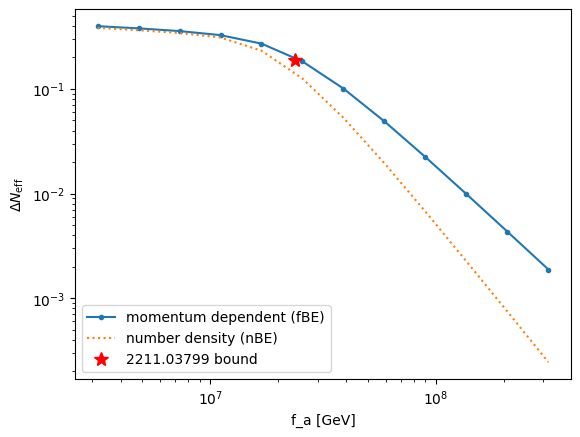

In [6]:
def delta_neff_from_Y(Y, T_final=fBE_pion.T_END, T_nu=3e-3):
    rho_a = np.pi**(14 / 3) / 30 * (s_ent(T_final) * Y / Zeta3) ** (4 / 3)
    rho_gamma = np.pi**2 / 15 * T_final**4
    return 8 / 7 * rho_a / rho_gamma * (h_s(T_final) / h_s(T_nu)) ** (-4 / 3)

f_vals = np.logspace(6.5, 8.5, 12)
dn_fbe = [delta_neff(q_grid, fBE_pion.solve_distribution(f, tables["pheno"], x_grid, q_grid), fBE_pion.T_END)
          for f in f_vals]
dn_nbe = [delta_neff_from_Y(fBE_pion.solve_number_density(f, tables["pheno"], x_grid)) for f in f_vals]

fig, ax = plt.subplots()
ax.loglog(f_vals, dn_fbe, "-o", ms=3, label="momentum dependent (fBE)")
ax.loglog(f_vals, dn_nbe, ":", label="number density (nBE)")
ax.plot(2.375e7, 0.19, "r*", ms=10, label="2211.03799 bound")
ax.set_xlabel("f_a [GeV]")
ax.set_ylabel(r"$\Delta N_\mathrm{eff}$")
ax.legend();

## 6. Reheating background

Pass an expansion history from `PyBolt.background` to the solvers. `fBE_pion.build_background` builds one
(temperatures in GeV) and `fBE_pion.run_window` picks the temperature range:

* start at $T_c = 150$ MeV, or at $T_\mathrm{max}$ if the bath never got that hot;
* stop at 15 MeV, or later if entropy is still being injected then. `PerturbativeReheating` hands over to
  the standard cosmology at about $T_\mathrm{rh}/3$; the run has to reach that point, because
  `delta_neff` only accounts for $g_{*S}$ dilution afterwards.

Below the rate table's lowest temperature (13.8 MeV) the pion rate is set to zero. Reheat temperatures
low enough that injection continues past neutrino decoupling (3 MeV, i.e. $T_\mathrm{rh} \lesssim 10$ MeV) are refused.

Lower $T_\mathrm{rh}$ means a faster expansion during production and more dilution afterwards, so fewer relic axions.

standard                         Delta N_eff at f_a = 2.565e+07 GeV: 0.1832


T_rh = 100 MeV (to 15.0 MeV)     Delta N_eff at f_a = 2.565e+07 GeV: 0.1126


T_rh = 50 MeV (to 15.0 MeV)      Delta N_eff at f_a = 2.565e+07 GeV: 0.0147


T_rh = 30 MeV (to 9.6 MeV)       Delta N_eff at f_a = 2.565e+07 GeV: 0.0012


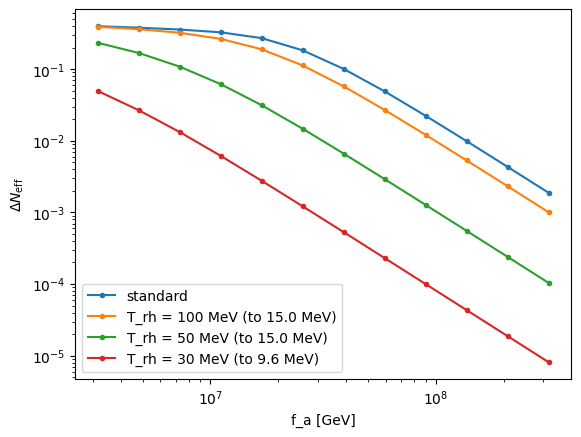

In [7]:
scenarios = [("standard", None), ("reheating", 0.100), ("reheating", 0.050), ("reheating", 0.030)]

fig, ax = plt.subplots()
for bg_name, T_rh in scenarios:
    background = fBE_pion.build_background(bg_name, T_rh=T_rh)
    T_start, T_end = fBE_pion.run_window(background)
    x_bg = fBE_pion.x_grid(fBE_pion.N_X, T_start, T_end)
    dn = [delta_neff(q_grid, fBE_pion.solve_distribution(f, tables["pheno"], x_bg, q_grid, background), T_end)
          for f in f_vals]
    label = "standard" if T_rh is None else f"T_rh = {T_rh*1e3:.0f} MeV (to {T_end*1e3:.1f} MeV)"
    ax.loglog(f_vals, dn, "-o", ms=3, label=label)
    print(f"{label:32s} Delta N_eff at f_a = {f_vals[5]:.3e} GeV: {dn[5]:.4f}")
ax.set_xlabel("f_a [GeV]")
ax.set_ylabel(r"$\Delta N_\mathrm{eff}$")
ax.legend();

### Distributions under reheating

Final spectra at $f_a = 2.375\times 10^7$ GeV for the same backgrounds. Runs end at different temperatures, so each spectrum
is first carried to a common temperature, $T_\nu = 3$ MeV. After injection has stopped, comoving entropy is
conserved: $f$ is unchanged along a comoving momentum, and $q = k/T$ rescales as
$q_\nu = q\,[g_{*S}(T_\nu)/g_{*S}(T_\mathrm{end})]^{1/3}$. This is the same dilution `delta_neff` applies.

* **Left:** $q^3 f$ at $T_\nu$. The area is proportional to $\Delta N_\mathrm{eff}$.
* **Right:** each spectrum divided by its own energy density, to compare shapes. The dashed line is a
  Bose–Einstein spectrum with unit energy density.

scenario                      dNeff     <E>/T_nu
standard                     0.2004         2.87


reheating, T_rh = 100 MeV    0.1256         2.75


reheating, T_rh = 50 MeV     0.0170         2.59


reheating, T_rh = 30 MeV     0.0014         2.30
sudden, T_rh = 50 MeV        0.0222         3.01
Bose-Einstein                               2.70


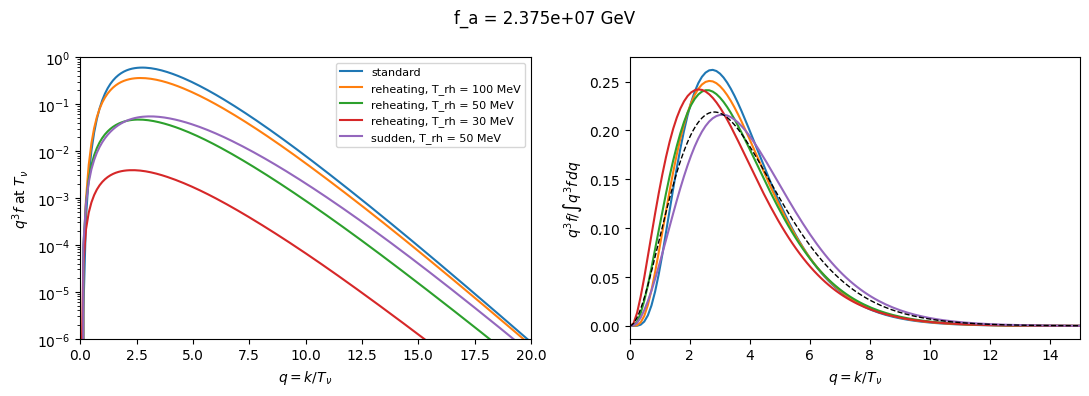

In [8]:
def spectrum_at_T_nu(q, F, T_end, T_nu=3e-3):
    q_nu = q * (h_s(T_nu) / h_s(T_end)) ** (1 / 3)
    return q_nu, F / q**2  # f is carried along unchanged

f_a = 2.375e7  # GeV
scenarios = [("standard", None), ("reheating", 0.100), ("reheating", 0.050),
             ("reheating", 0.030), ("sudden", 0.050)]

fig, (ax_abs, ax_shape) = plt.subplots(1, 2, figsize=(11, 4))
print(f"{'scenario':26s} {'dNeff':>8s} {'<E>/T_nu':>12s}")
for bg_name, T_rh in scenarios:
    background = fBE_pion.build_background(bg_name, T_rh=T_rh)
    T_start, T_end = fBE_pion.run_window(background)
    x_bg = fBE_pion.x_grid(fBE_pion.N_X, T_start, T_end)
    F = fBE_pion.solve_distribution(f_a, tables["pheno"], x_bg, q_grid, background)
    q_nu, f = spectrum_at_T_nu(q_grid, F, T_end)

    label = "standard" if T_rh is None else f"{bg_name}, T_rh = {T_rh*1e3:.0f} MeV"
    energy = np.trapezoid(q_nu**3 * f, q_nu)
    mean_energy = energy / np.trapezoid(q_nu**2 * f, q_nu)  # <E>/T_nu per axion
    print(f"{label:26s} {delta_neff(q_grid, F, T_end):8.4f} {mean_energy:12.2f}")

    ax_abs.semilogy(q_nu, q_nu**3 * f, label=label)
    ax_shape.plot(q_nu, q_nu**3 * f / energy, label=label)

q_be = np.linspace(0.01, 30, 400)
ax_shape.plot(q_be, q_be**3 / np.expm1(q_be) / (np.pi**4 / 15), "k--", lw=1, label="Bose-Einstein")
print(f"{'Bose-Einstein':26s} {'':8s} {np.pi**4 / 15 / (2 * Zeta3):12.2f}")

ax_abs.set_ylim(1e-6, 1)
ax_abs.set_xlim(0, 20)
ax_abs.set_xlabel(r"$q = k/T_\nu$")
ax_abs.set_ylabel(r"$q^3 f$ at $T_\nu$")
ax_abs.legend(fontsize=8)
ax_shape.set_xlim(0, 15)
ax_shape.set_xlabel(r"$q = k/T_\nu$")
ax_shape.set_ylabel(r"$q^3 f / \int q^3 f\, dq$")
fig.suptitle(f"f_a = {f_a:.3e} GeV")
fig.tight_layout()

## 7. Command line

**Scan.** Writes `run.dat` (one row per $f_a$: `f_a, F(q)...`, same format as the lepton runs) and
`run_dneff.dat` (`f_a, dNeff`):

```bash
python fBE_pion.py --f_min 1e6 --f_max 1e9 --f_num 30 --output run.dat
python fBE_pion.py --mode nbe --output run_nbe.dat                     # number density instead
python fBE_pion.py --table data/pion_rate_lo.npz --output run_lo.dat   # LO chiPT rate
python fBE_pion.py --bg reheating --t-rh 0.05 --output run_rh50.dat      # T_rh = 50 MeV (GeV units)
python fBE_pion.py --bg reheating --t-rh 0.05 --t-max 0.1 --output run.dat # bath never above 100 MeV
```

**Rebuild a rate table.** About a minute on 14 cores; only needed after changing the amplitudes or the grid:

```bash
python tabulate_pion_rate.py --amplitude pheno --nproc 14 --output data/pion_rate_pheno.npz
```

The cell below runs a small scan in a temporary directory and reads the output back.

In [9]:
import os, subprocess, sys, tempfile

with tempfile.TemporaryDirectory() as tmp:
    out = os.path.join(tmp, "run.dat")
    subprocess.run([sys.executable, "fBE_pion.py", "--f_min", "1e7", "--f_max", "1e8",
                    "--f_num", "4", "--output", out], check=True, capture_output=True)
    dneff = np.loadtxt(os.path.join(tmp, "run_dneff.dat"), delimiter=",")
    spectra = np.loadtxt(out, delimiter=",", comments="#")

print("f_a [GeV]     dNeff")
for row in dneff:
    print(f"{row[0]:.3e}   {row[1]:.4f}")
print("spectra shape (rows = f_a values; column 0 = f_a, rest = F on the q grid):", spectra.shape)

f_a [GeV]     dNeff
1.000e+07   0.3362
2.154e+07   0.2220
4.642e+07   0.0755
1.000e+08   0.0183
spectra shape (rows = f_a values; column 0 = f_a, rest = F on the q grid): (4, 251)
